In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
from PIL import Image #to open images
from io import BytesIO #to store images

### Adding images to plots

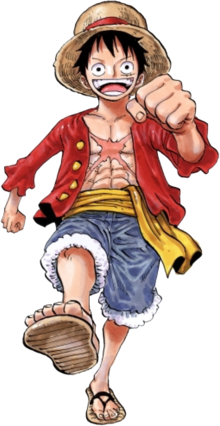

In [12]:
# Get image from internet
headers = {
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'image/*,*/*;q=0.8',
    'Referer': 'https://en/wikipedia.org/'
}
response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png', headers=headers)
image_file = BytesIO(response.content)
image = Image.open(image_file)
image

In [13]:
x=np.array(['Luffy','Zoro','Nami','Usopp','Sanji'])
y1=np.array([110,180,240,99,220])
y2=np.array([170,100,90,120,50])

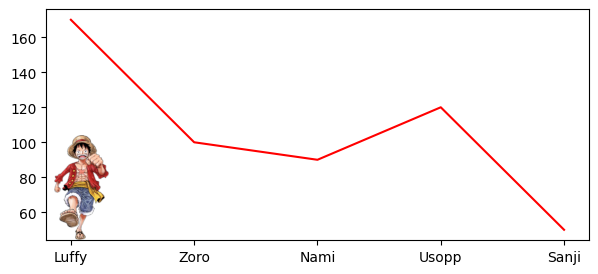

In [ ]:
# Add an image to a plot
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(x,y2, color='red')
ax_image = fig.add_axes([0.1, #x coordinate of bottom left (on figure, not axis)
                         0.11, #y coordinate
                         0.15, #image width
                         0.35]) #image height
ax_image.imshow(image) #add image to the box
ax_image.axis('off') #hide the axis of the box

# Save the plot
path = "C:/Users/songy/Documents/Others/DSI/visualization"
filename = 'Luffy.png'
plt.savefig(f"{path}/{filename}", dpi=300)

### Exploring Seaborn

In [3]:
# Install additional libraries
import seaborn as sns

In [4]:
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [5]:
tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

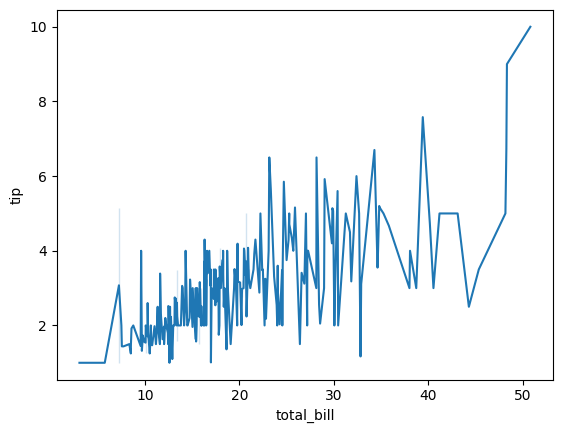

In [6]:

# Basic seaborn plot
sns.lineplot(data=tips,
             x='total_bill',
             y='tip')

[Text(0.5, 1.0, 'Tip vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

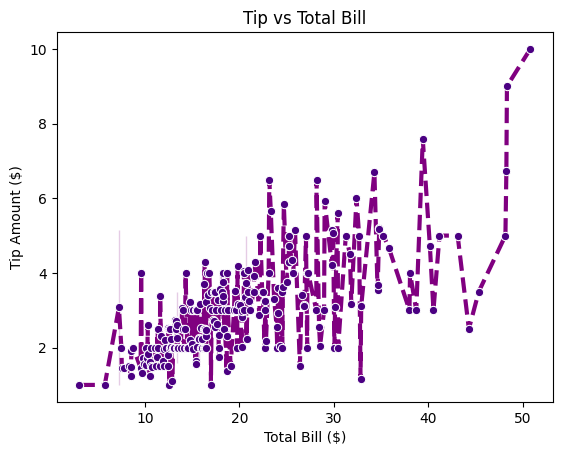

In [8]:
# Premad styles, additional aesthetics
#sns.set_style('darkgrid')
tipgraph = sns.lineplot(data=tips,
             x='total_bill',
             y='tip',
             color='purple',
             linestyle='--',
             marker='o',
             linewidth=3,
             markerfacecolor='indigo')
tipgraph.set(title = 'Tip vs Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

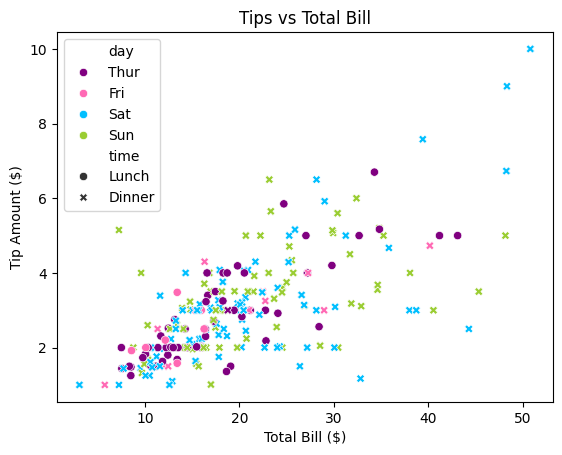

In [ ]:
# Seaborn allows adding multiple variables with different visual elements
tipgraph = sns.scatterplot(data=tips,
                           x='total_bill',
                           y='tip',
                           style='time', #different markers for different times of day
                           hue='day', #different colors for different days
                           palette=['purple','hotpink','deepskyblue','yellowgreen'])
tipgraph.set(title='Tips vs Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

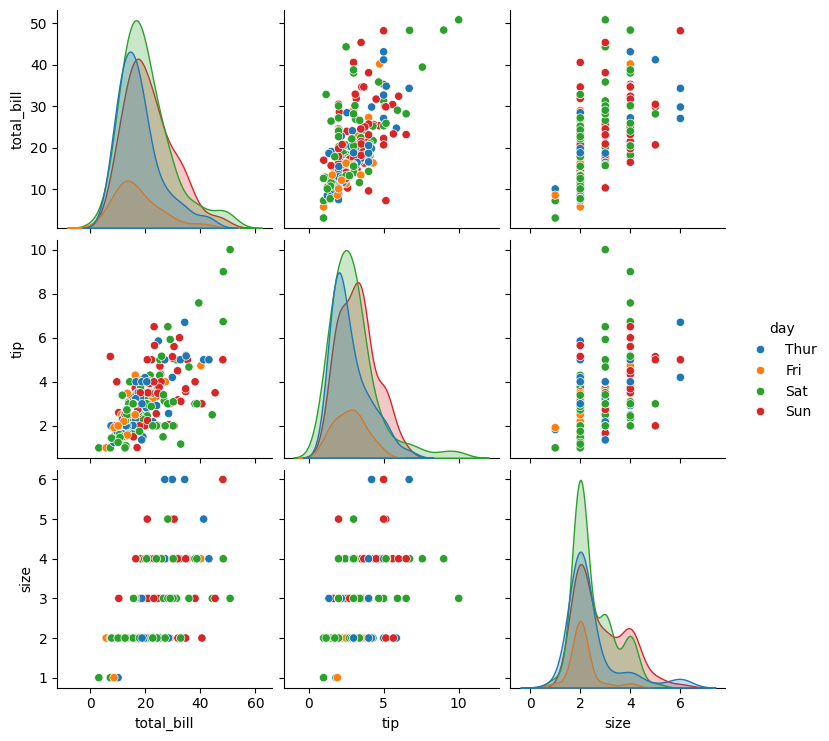

In [ ]:
# Pairplot
sns.pairplot(data=tips, #9 plots because 3 numerical variables
             hue='day')
# Pairplot is great for exploring relationships between multiple numerical variables

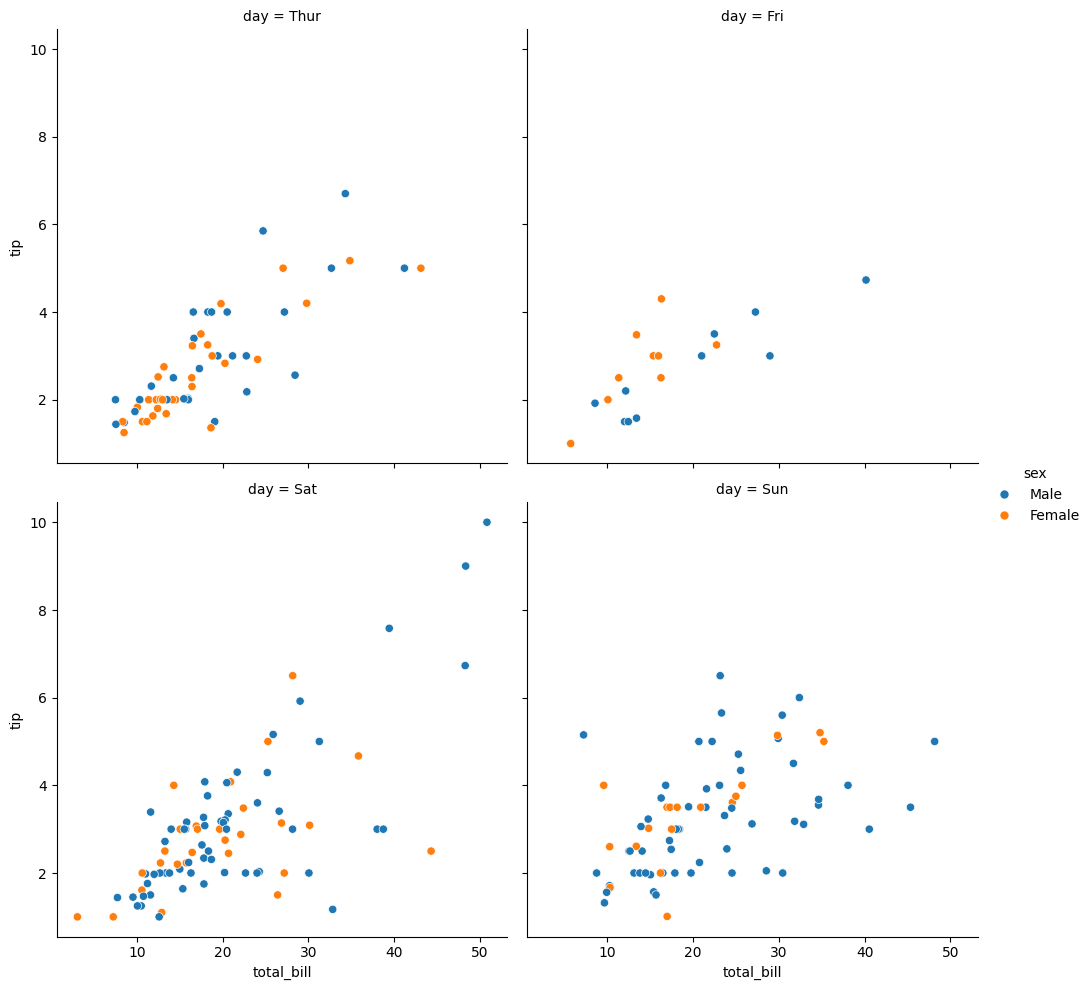

In [15]:
# Relplot
daysplot = sns.relplot(data=tips,
                      x='total_bill',
                      y='tip',
                      hue='sex', #different colors for gender
                      col='day', #different plots for different days
                      kind='scatter', #scatter plot
                      col_wrap=2) #wrap after 2 plots per row

### Plotly

In [ ]:
x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

In [ ]:
# Plotly interactive plot 
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1)) #bar plot
graph.update_layout(title='Pirate Scores',
                    xaxis_title='Pirates',
                    yaxis_title='Score')
graph.show()
# Plotly allows hovering over the bars to see data labels
# Also zooming in bars and dragging axis
# Export plotly graph as html
# graph.write_html(f"{path}/pirate_scores.html")

In [ ]:
# Customize plotly plots
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1,
                           mode='markers', #only plot points
                          marker=dict( #customize marker style
                              size=15,
                              color='hotpink',
                              opacity=1, #transparency
                              line=dict(width=5, color='purple') #outline color
                          ) ))
graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Score',
    width=500,
    height=500
)

### Wordcloud

In [ ]:
# Wordcloud is for qualitative data
df = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv',
                 on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

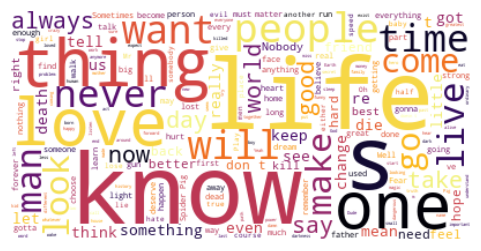

In [ ]:
# Join all text from each rom into a single string
text = " ".join(each for each in df.quote) #separate each quote with a space

# Generate wordcloud image
wordcloud = WordCloud(background_color='white',
                      colormap='inferno').generate(text)

# Use matplotlib to display the wordcloud
fig, ax = plt.subplots(figsize=(7,3))
ax.imshow(wordcloud, 
          interpolation='bilinear') #smooth the image
ax.axis('off')
# Each time the code is run, a different wordcloud is generated, words can vary in position

### Venn diagram with matplotlib_venn

c:\Users\songy\Documents\Others\DSI\visualization-env\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



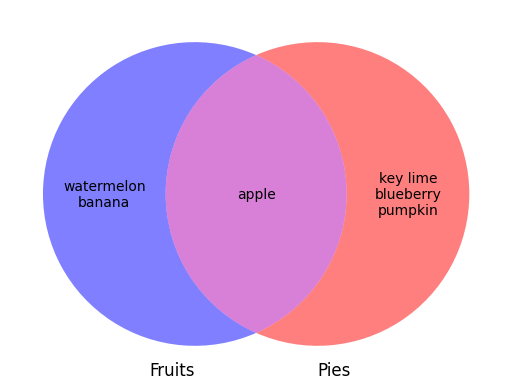

In [29]:
# Venn diagram
A = set(['apple', 'banana', 'watermelon'])
B = set(['pumpkin', 'blueberry', 'apple', 'key lime'])

diagram = venn2_unweighted([A,B],
                           set_labels=('Fruits', 'Pies'), #labels for each set
                           set_colors=('blue', 'red'), #colors for each set
                           alpha=0.5) #transparency

# Modify the venn diagram
diagram.get_label_by_id('10').set_text('\n'.join(A - B)) #'10' means inside A outside B, '\n' for new line
diagram.get_label_by_id('01').set_text('\n'.join(B - A)) #'01' means inside B outside A
diagram.get_label_by_id('11').set_text('\n'.join(A & B)) #'11' means inside both A and B

plt.show()